In [ ]:
!pip install torch

In [ ]:
!pip install -U "accelerate>=1.1.0" "transformers[torch]"

In [ ]:
!pip3 install datasets

In [ ]:
!pip install transformers

In [ ]:
!pip uninstall transformers accelerate -y

!pip install \
transformers==4.46.3 \
accelerate==1.0.1 \
datasets==3.1.0 \
evaluate==0.4.3

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Paths & config
PROJECT_ROOT = Path.cwd().parents[1]  # because notebook is under notebooks/bert_model
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models" / "bert_sentiment_model"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "bert"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

BASE_MODEL = "distilbert-base-uncased"

TEXT_COL = "text_review_categories_tips"
TARGET_COL = "target_sentiment"

MAX_LENGTH = 256
TRAIN_SAMPLE_SIZE = 50000
VAL_SIZE = 0.1

In [4]:
# Load train/test data
train_df = pd.read_pickle(PROCESSED_DIR / "bert_train_model_df.pkl")
test_df = pd.read_pickle(PROCESSED_DIR / "bert_test_model_df.pkl")

train_df.shape, test_df.shape

((800000, 20), (200000, 20))

In [5]:
# Prepare labels
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {v: k for k, v in label2id.items()}

train_df = train_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df[TARGET_COL].map(label2id)
test_df["label"] = test_df[TARGET_COL].map(label2id)

train_df[[TARGET_COL, "label"]].head()

,target_sentiment,label
0,negative,0
1,positive,2
2,negative,0
3,negative,0
4,positive,2


In [6]:
# Sample training data only
# We sample only from the training set.
# The test set remains untouched for final evaluation.

if len(train_df) > TRAIN_SAMPLE_SIZE:
    train_sample = (
        train_df
        .groupby(TARGET_COL, group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, int(TRAIN_SAMPLE_SIZE * len(x) / len(train_df))),
            random_state=RANDOM_STATE
        ))
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    train_sample = train_df.copy()

train_sample[TARGET_COL].value_counts(normalize=True)

target_sentiment
positive    0.668193
negative    0.265265
neutral     0.066541
Name: proportion, dtype: float64

In [7]:
# Train/validation split
# Validation split is created only from the training data.
# This prevents test information from leaking into model selection.

bert_train_df, bert_val_df = train_test_split(
    train_sample,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_sample["label"]
)

bert_train_df.shape, bert_val_df.shape

((44999, 21), (5000, 21))

In [8]:
# Convert to Hugging Face datasets
def keep_required_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df[[TEXT_COL, "label"]].rename(columns={TEXT_COL: "text"}).reset_index(drop=True)


hf_train = Dataset.from_pandas(keep_required_columns(bert_train_df))
hf_val = Dataset.from_pandas(keep_required_columns(bert_val_df))
hf_test = Dataset.from_pandas(keep_required_columns(test_df))

hf_train, hf_val, hf_test

(Dataset({
     features: ['text', 'label'],
     num_rows: 44999
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 5000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 200000
 }))

In [9]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


hf_train_tokenized = hf_train.map(tokenize_batch, batched=True)
hf_val_tokenized = hf_val.map(tokenize_batch, batched=True)
hf_test_tokenized = hf_test.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200000/200000 [00:14<00:00, 13985.50 examples/s]


In [10]:
# Model
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted")
    }

In [12]:
# Training arguments
training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=RANDOM_STATE
)

In [13]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train_tokenized,
    eval_dataset=hf_val_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [14]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.222300,0.247759,0.914800,0.731745,0.905359
2,0.174800,0.239002,0.922400,0.772076,0.918389


TrainOutput(global_step=5626, training_loss=0.22298519466425912, metrics={'train_runtime': 7599.6811, 'train_samples_per_second': 11.842, 'train_steps_per_second': 0.74, 'total_flos': 5923112145306048.0, 'train_loss': 0.22298519466425912, 'epoch': 2.0})

In [15]:
# Validate
val_metrics = trainer.evaluate(hf_val_tokenized)
val_metrics

{'eval_loss': 0.23900170624256134,
 'eval_accuracy': 0.9224,
 'eval_macro_f1': 0.7720759300062564,
 'eval_weighted_f1': 0.9183894196401947,
 'eval_runtime': 93.3989,
 'eval_samples_per_second': 53.534,
 'eval_steps_per_second': 1.681,
 'epoch': 2.0}

In [16]:
# Final test evaluation
test_predictions = trainer.predict(hf_test_tokenized)

test_logits = test_predictions.predictions
test_pred_ids = np.argmax(test_logits, axis=1)

test_true_ids = np.array(hf_test_tokenized["label"])

bert_accuracy = accuracy_score(test_true_ids, test_pred_ids)
bert_macro_f1 = f1_score(test_true_ids, test_pred_ids, average="macro")
bert_weighted_f1 = f1_score(test_true_ids, test_pred_ids, average="weighted")

bert_accuracy, bert_macro_f1, bert_weighted_f1

(0.91826, 0.7790478039594243, 0.9146103529768999)

In [17]:
# Classification report
target_names = ["negative", "neutral", "positive"]

report = classification_report(
    test_true_ids,
    test_pred_ids,
    target_names=target_names,
    output_dict=True
)

pd.DataFrame(report).T

,precision,recall,f1-score,support
negative,0.895802,0.929941,0.912553,56153.00000
neutral,0.521728,0.408986,0.458529,14355.00000
positive,0.962500,0.969651,0.966062,129492.00000
accuracy,0.918260,0.918260,0.918260,0.91826
macro avg,0.793343,0.769526,0.779048,200000.00000
weighted avg,0.912137,0.918260,0.914610,200000.00000


In [18]:
# Confusion matrix
cm = confusion_matrix(test_true_ids, test_pred_ids)

cm_df = pd.DataFrame(
    cm,
    index=[f"actual_{x}" for x in target_names],
    columns=[f"pred_{x}" for x in target_names]
)

cm_norm_df = cm_df.div(cm_df.sum(axis=1), axis=0).round(4)

cm_df, cm_norm_df

(                 pred_negative  pred_neutral  pred_positive
 actual_negative          52219          2739           1195
 actual_neutral            4787          5871           3697
 actual_positive           1287          2643         125562,
                  pred_negative  pred_neutral  pred_positive
 actual_negative         0.9299        0.0488         0.0213
 actual_neutral          0.3335        0.4090         0.2575
 actual_positive         0.0099        0.0204         0.9697)

In [19]:
# Save model
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

with open(MODEL_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "label2id": label2id,
            "id2label": id2label
        },
        f,
        indent=2
    )

In [20]:
# Save metrics
bert_metrics = {
    "base_model": BASE_MODEL,
    "text_col": TEXT_COL,
    "max_length": MAX_LENGTH,
    "train_sample_size": len(train_sample),
    "validation_size": len(bert_val_df),
    "test_size": len(test_df),
    "accuracy": bert_accuracy,
    "macro_f1": bert_macro_f1,
    "weighted_f1": bert_weighted_f1,
    "classification_report": report
}

with open(OUTPUT_DIR / "bert_model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(bert_metrics, f, indent=2)

cm_df.to_csv(OUTPUT_DIR / "bert_confusion_matrix.csv")
cm_norm_df.to_csv(OUTPUT_DIR / "bert_confusion_matrix_normalized.csv")

bert_metrics

{'base_model': 'distilbert-base-uncased',
 'text_col': 'text_review_categories_tips',
 'max_length': 256,
 'train_sample_size': 49999,
 'validation_size': 5000,
 'test_size': 200000,
 'accuracy': 0.91826,
 'macro_f1': 0.7790478039594243,
 'weighted_f1': 0.9146103529768999,
 'classification_report': {'negative': {'precision': 0.8958022404062237,
   'recall': 0.9299414100760423,
   'f1-score': 0.912552644915506,
   'support': 56153.0},
  'neutral': {'precision': 0.5217275393228472,
   'recall': 0.4089864158829676,
   'f1-score': 0.4585285848172446,
   'support': 14355.0},
  'positive': {'precision': 0.9625001916384319,
   'recall': 0.9696506347882494,
   'f1-score': 0.9660621821455225,
   'support': 129492.0},
  'accuracy': 0.91826,
  'macro avg': {'precision': 0.7933433237891676,
   'recall': 0.7695261535824197,
   'f1-score': 0.7790478039594243,
   'support': 200000.0},
  'weighted avg': {'precision': 0.9121372842407698,
   'recall': 0.91826,
   'f1-score': 0.9146103529768999,
   'supp

In [21]:
# Compare with existing TF-IDF model
tfidf_metrics_path = PROJECT_ROOT / "outputs" / "model_metrics.json"

with open(tfidf_metrics_path, "r", encoding="utf-8") as f:
    tfidf_metrics = json.load(f)

comparison_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "accuracy": tfidf_metrics["accuracy"],
            "macro_f1": tfidf_metrics["macro_f1"],
            "weighted_f1": tfidf_metrics["weighted_f1"],
            "deployment_complexity": "Low",
            "interpretability": "High",
            "inference_cost": "Low"
        },
        {
            "model": "DistilBERT",
            "accuracy": bert_accuracy,
            "macro_f1": bert_macro_f1,
            "weighted_f1": bert_weighted_f1,
            "deployment_complexity": "Medium",
            "interpretability": "Medium-Low",
            "inference_cost": "Medium"
        }
    ]
)

comparison_df

,model,accuracy,macro_f1,weighted_f1,deployment_complexity,interpretability,inference_cost
0,TF-IDF + Logistic Regression,0.875785,0.748692,0.885009,Low,High,Low
1,DistilBERT,0.918260,0.779048,0.914610,Medium,Medium-Low,Medium


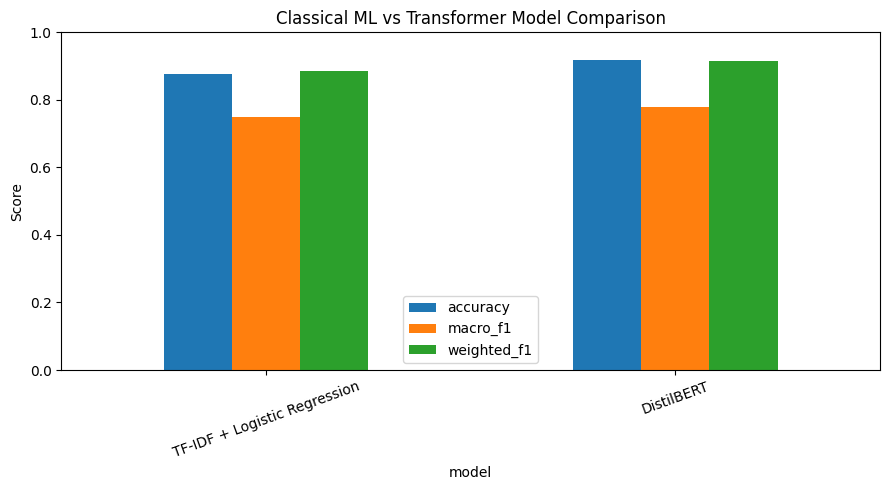

In [22]:
# Plot comparison
import matplotlib.pyplot as plt

plot_df = comparison_df.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]]

plot_df.plot(kind="bar", figsize=(9, 5))

plt.title("Classical ML vs Transformer Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()